
#Simple CNN Implemented using Keras.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)
# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])
# Compile the model
model.compile(optimizer="adam",

loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - accuracy: 0.9135 - loss: 0.2869 - val_accuracy: 0.9862 - val_loss: 0.0419
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 29ms/step - accuracy: 0.9869 - loss: 0.0418 - val_accuracy: 0.9891 - val_loss: 0.0353
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9913 - loss: 0.0274 - val_accuracy: 0.9875 - val_loss: 0.0370
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 30ms/step - accuracy: 0.9923 - loss: 0.0229 - val_accuracy: 0.9909 - val_loss: 0.0315
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 28ms/step - accuracy: 0.9958 - loss: 0.0140 - val_accuracy: 0.9917 - val_loss: 0.0282
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9890 - loss: 0.0361
Test accuracy: 0.9917
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


#Exercise.

#Implement an End to End CNN Model for Image Classification Task.
Objective
In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon
using TensorFlow and Keras.
Task 1: Data Understanding and Visualization:

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from google.colab import drive

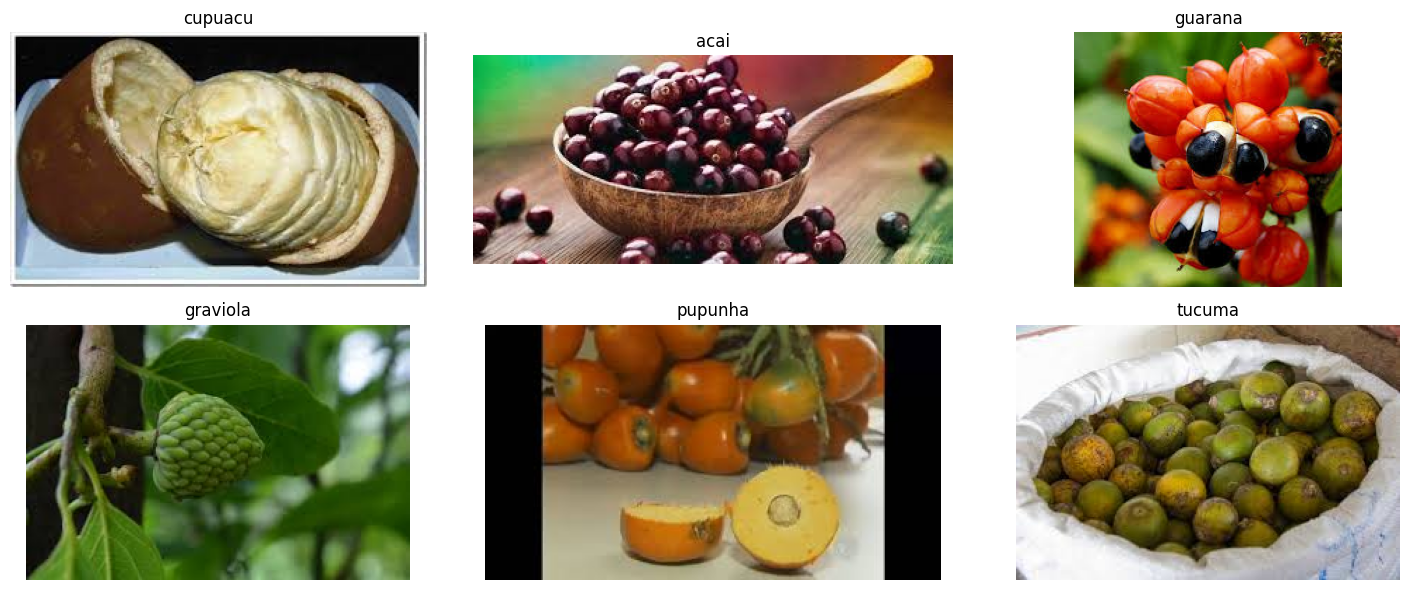

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Path to training and test folders (update these to your actual dataset path in Drive)
train_dir1 = '/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train'
test_dir = '/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/test'

# Get the list of class directories
class_names = os.listdir(train_dir1)
class_names = [cls for cls in class_names if os.path.isdir(os.path.join(train_dir1, cls))]

# Select one random image from each class
selected_images = []
for cls in class_names:
    class_path = os.path.join(train_dir1, cls)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    if image_files:  # Ensure the class folder is not empty
        random_image = random.choice(image_files)
        selected_images.append((cls, os.path.join(class_path, random_image)))

# Check if there are any images selected
if selected_images:
    num_images = len(selected_images)

    # Calculate the number of columns required (half of the number of images, rounded up)
    cols = (num_images + 1) // 2

    # Create subplots with 2 rows and the calculated number of columns
    fig, axes = plt.subplots(2, cols, figsize=(15, 6))

    # Flatten the axes array for easier indexing if there are more than one row
    axes = axes.flatten()

    # Display the images
    for idx, (cls, img_path) in enumerate(selected_images):
        img = mpimg.imread(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(cls)
        axes[idx].axis('off')

    # Hide any extra axes if the number of selected images is less than 2 * cols
    for i in range(num_images, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("No images found to display.")


#Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”


In [ ]:
corrupted_images = []

# Loop through all class subdirectories
for class_name in os.listdir(train_dir1):
    class_path = os.path.join(train_dir1, class_name)
    if os.path.isdir(class_path):
        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)
            try:
                with Image.open(file_path) as img:
                    img.verify()  # Check image integrity
            except (IOError, SyntaxError, Exception):
                corrupted_images.append(file_path)
                os.remove(file_path)
                print(f"Removed corrupted image: {file_path}")

# Final report
if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal Corrupted Images Removed: {len(corrupted_images)}")

Removed corrupted image: /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train/cupuacu/download.jpeg
Removed corrupted image: /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train/cupuacu/download (1).jpeg
Removed corrupted image: /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train/cupuacu/images (7).jpeg
Removed corrupted image: /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train/cupuacu/images (13).jpeg
Removed corrupted image: /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train/cupuacu/images (10).jpeg
Removed corrupted image: /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train/cupuacu/images (5).jpeg
Removed corrupted image: /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train/cupuacu/images (11).jpeg
Removed corrupted image: /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train/cupuacu/images (8).jpeg
Removed corrupted image: /content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train/cupuacu/images (2).jpeg
Removed corrupted image: /content/drive/MyD

#Loading and Preprocessing Image Data in keras:

Scanning folder: /content/drive/MyDrive/train (0 files)
Scanning folder: /content/drive/MyDrive/train/graviola (15 files)
Scanning folder: /content/drive/MyDrive/train/tucuma (15 files)
Scanning folder: /content/drive/MyDrive/train/guarana (15 files)
Scanning folder: /content/drive/MyDrive/train/cupuacu (15 files)
Scanning folder: /content/drive/MyDrive/train/pupunha (15 files)
Scanning folder: /content/drive/MyDrive/train/acai (15 files)

 Total images checked: 90
  Total corrupted images removed: 0
Scanning folder: /content/drive/MyDrive/test (0 files)
Scanning folder: /content/drive/MyDrive/test/graviola (5 files)
Scanning folder: /content/drive/MyDrive/test/guarana (5 files)
Scanning folder: /content/drive/MyDrive/test/acai (5 files)
Scanning folder: /content/drive/MyDrive/test/cupuacu (5 files)
Scanning folder: /content/drive/MyDrive/test/tucuma (5 files)
Scanning folder: /content/drive/MyDrive/test/pupunha (5 files)

 Total images checked: 30
  Total corrupted images removed: 0


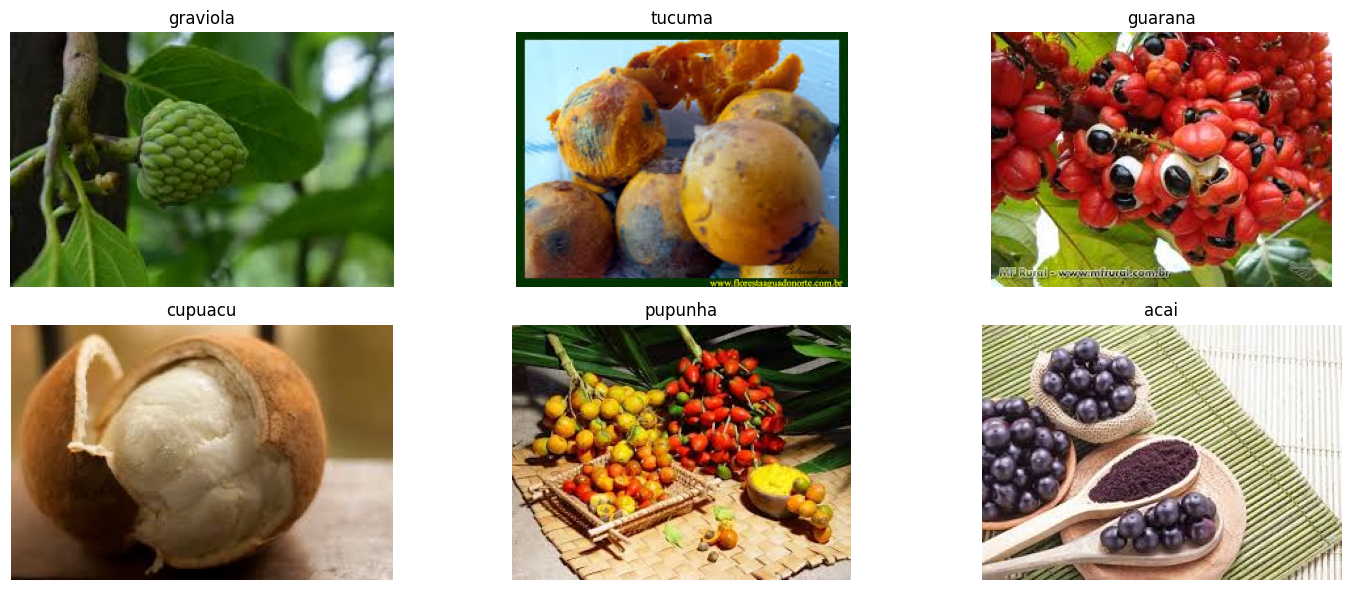

In [ ]:
import os
from PIL import Image

import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def remove_corrupted_images(directory):
    total_checked = 0
    total_deleted = 0

    for root, _, files in os.walk(directory):
      print(f"Scanning folder: {root} ({len(files)} files)")
      for filename in files:
            file_path = os.path.join(root, filename)
            try:
                with Image.open(file_path) as img:
                    img.verify()  # Verify if it's a proper image
                total_checked += 1
            except (IOError, SyntaxError):
                print(f"Corrupted image found and removed: {file_path}")
                os.remove(file_path)
                total_deleted += 1

    print(f"\n Total images checked: {total_checked + total_deleted}")
    print(f"  Total corrupted images removed: {total_deleted}")

# Paths
train = '/content/drive/MyDrive/train'
test = '/content/drive/MyDrive/test'

# Remove corrupted images in both train and test directories
remove_corrupted_images(train)
remove_corrupted_images(test)




# Get the list of class directories
class_names = os.listdir(train)
class_names = [cls for cls in class_names if os.path.isdir(os.path.join(train, cls))]

# Select one random image from each class
selected_images = []
for cls in class_names:
    class_path = os.path.join(train, cls)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    if image_files:  # Ensure the class folder is not empty
        random_image = random.choice(image_files)
        selected_images.append((cls, os.path.join(class_path, random_image)))

# Check if there are any images selected
if selected_images:
    num_images = len(selected_images)

    # Calculate the number of columns required (half of the number of images, rounded up)
    cols = (num_images + 1) // 2

    # Create subplots with 2 rows and the calculated number of columns
    fig, axes = plt.subplots(2, cols, figsize=(15, 6))

    # Flatten the axes array for easier indexing if there are more than one row
    axes = axes.flatten()

    # Display the images
    for idx, (cls, img_path) in enumerate(selected_images):
        img = mpimg.imread(img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(cls)
        axes[idx].axis('off')

    # Hide any extra axes if the number of selected images is less than 2 * cols
    for i in range(num_images, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("No images found to display.")


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Load cleaned datasets
train_ds = image_dataset_from_directory(
    train,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(128, 128),
    batch_size=16
)


val_ds = image_dataset_from_directory(
    train,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(128, 128),
    batch_size=16
)

test_ds = image_dataset_from_directory(
    test,
    image_size=(128, 128),
    batch_size=16,
    shuffle=False
)


# ✅ Get number of classes here
class_names = train_ds.class_names
num_classes = len(class_names)



Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


In [ ]:
# Optional: prefetching for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

#Compile and Train the Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# Load cleaned datasets
train_ds = image_dataset_from_directory(
    train,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(128, 128),
    batch_size=16
)


class_names = train_ds.class_names
num_classes = len(class_names)

model = Sequential([
    Input(shape=(128, 128, 3)),  # ✅ Use this instead of passing input_shape to Conv2D
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Found 90 files belonging to 6 classes.
Using 72 files for training.


#Train the Model with Callbacks

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_cb = ModelCheckpoint("best_fruit_model.h5", save_best_only=True)
earlystop_cb = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint_cb, earlystop_cb]
)


Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.1125 - loss: 691.1366

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 522ms/step - accuracy: 0.1215 - loss: 705.5978 - val_accuracy: 0.1111 - val_loss: 310.6256
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.1514 - loss: 208.5835

5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 728ms/step - accuracy: 0.1586 - loss: 198.0387 - val_accuracy: 0.1667 - val_loss: 17.1095
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.4580 - loss: 8.4918

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 465ms/step - accuracy: 0.4742 - loss: 7.9385 - val_accuracy: 0.2222 - val_loss: 4.3812
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.8042 - loss: 0.8391

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step - accuracy: 0.8090 - loss: 0.8315 - val_accuracy: 0.3333 - val_loss: 3.9278
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9708 - loss: 0.2063

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 486ms/step - accuracy: 0.9688 - loss: 0.2066 - val_accuracy: 0.2778 - val_loss: 1.8335
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 391ms/step - accuracy: 0.9578 - loss: 0.1994 - val_accuracy: 0.3333 - val_loss: 5.3005
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 536ms/step - accuracy: 0.9795 - loss: 0.0549 - val_accuracy: 0.3889 - val_loss: 5.1619
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 411ms/step - accuracy: 1.0000 - loss: 0.0358 - val_accuracy: 0.5000 - val_loss: 2.8929
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 406ms/step - accuracy: 1.0000 - loss: 0.0121 - val_accuracy: 0.5556 - val_loss: 2.7002
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 398ms/step - accuracy: 0.9737 - loss: 0.2151 - val_accuracy: 0.6111 - val_loss: 3.1899
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 432ms/step - accuracy: 0.9841 - loss: 0.0616 - val_accuracy: 0.5000 - val_loss: 3.7414
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 628ms/step - accuracy: 0.9893 - loss: 0.0278 - val_accuracy: 0.3889 - val_loss: 

# Evaluate the Model

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4125 - loss: 1.7334

Test Loss: 1.7938, Test Accuracy: 0.4000


#Save and Load the Model

In [ ]:
# Save
model.save("final_fruit_model.h5")

# Load
loaded_model = tf.keras.models.load_model("final_fruit_model.h5")

# Evaluate again
loss, accuracy = loaded_model.evaluate(test_ds)
print(f"\nReloaded Model -> Test Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.4125 - loss: 1.7334

Reloaded Model -> Test Loss: 1.7938, Accuracy: 0.4000


#Make Predictions and Generate a Classification Report

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Step 1: Load test dataset and extract class names
test_ds = image_dataset_from_directory(
    test,
    image_size=(128, 128),
    batch_size=16,
    shuffle=False
)
class_names = test_ds.class_names  # ✅ Save before prefetching

# Step 2: Prefetch for performance
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# Step 3: Evaluate
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_pred_probs = loaded_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 4: Report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))



Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step

Classification Report:
              precision    recall  f1-score   support

        acai       0.42      1.00      0.59         5
     cupuacu       0.50      0.20      0.29         5
    graviola       0.00      0.00      0.00         5
     guarana       0.50      0.80      0.62         5
     pupunha       0.20      0.20      0.20         5
      tucuma       0.33      0.20      0.25         5

    accuracy                           0.40        30
   macro avg       0.33      0.40      0.32        30
weighted avg       0.33      0.40      0.32        30



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Visualization Plot Accuracy and Loss Graphs

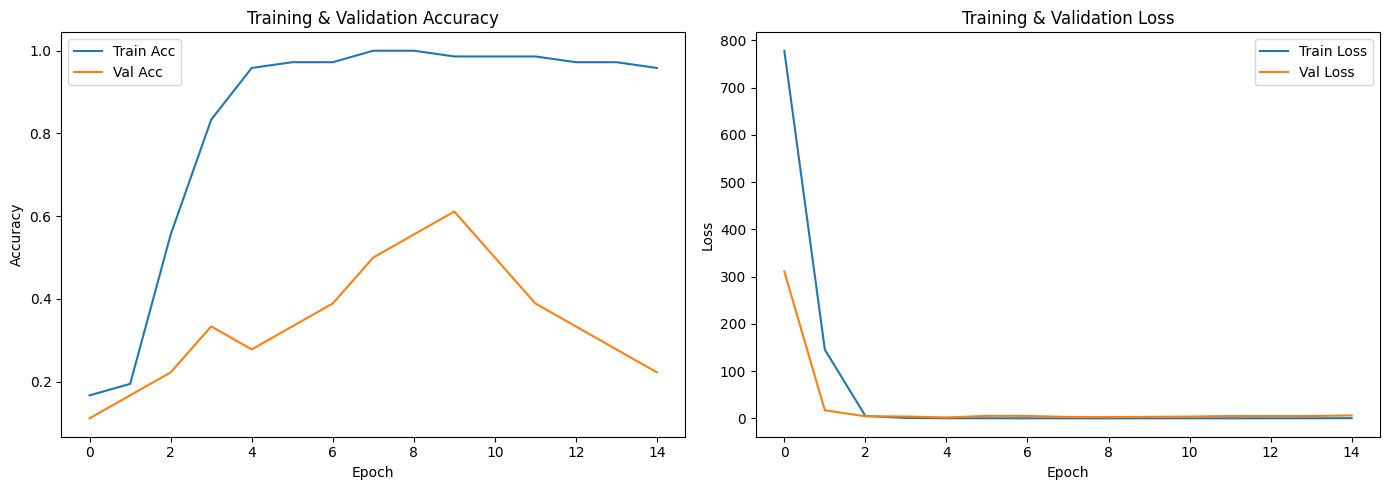

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
